In [1]:
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt


In [3]:
sample_img_name = "image_512.jpg"
folder = "data/image_folder"

img_path = os.path.join(folder, sample_img_name)
img = cv.imread(img_path)

In [4]:
print(img_path)

data/image_folder/image_512.jpg


In [5]:
print(img.shape)

(360, 640, 3)


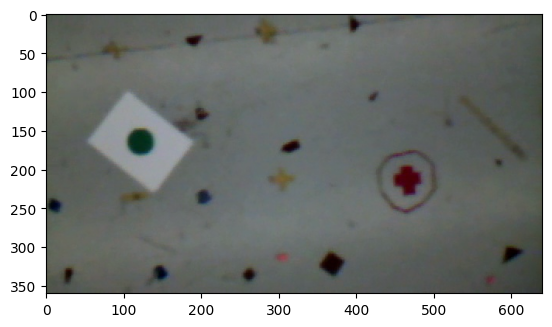

In [6]:
plt.imshow(img)

In [7]:
img_gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

In [8]:
print(img_gray.shape)

(360, 640)


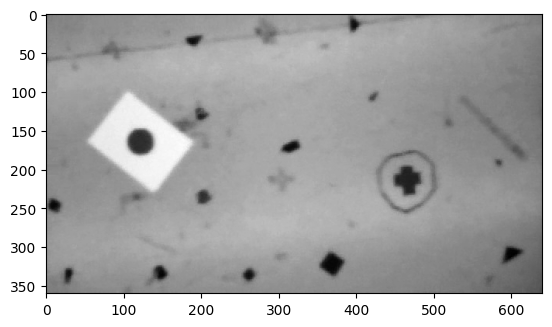

In [9]:
plt.imshow(img_gray, cmap='gray')

In [10]:
blurred = cv.GaussianBlur(img_gray, (3, 3), 0)
filtered_LoG = cv.Laplacian(blurred, cv.CV_16S, ksize=3)

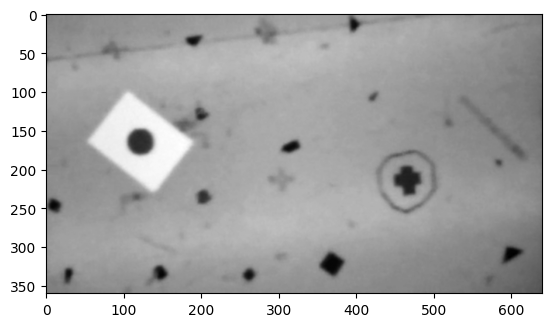

In [11]:
plt.imshow(blurred, cmap='gray')

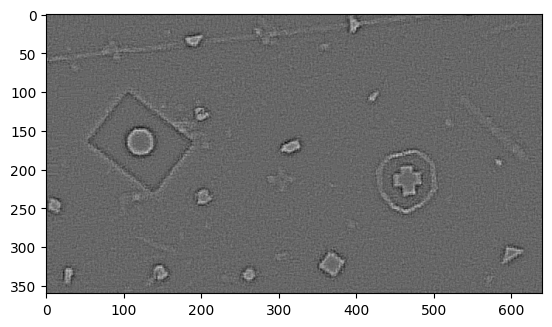

In [12]:
plt.imshow(filtered_LoG, cmap='gray')

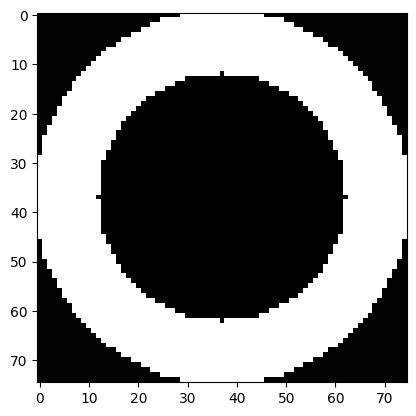

In [13]:
blank = np.ones((75,75), np.float64)
# cv.circle(	img, center, radius, color[, thickness[, lineType[, shift]]]	) -> 	img
circle_template_0 = cv.circle(blank,(37,37),np.round(75/2).astype(np.uint8) , 255, -1)
circle_template = cv.circle(circle_template_0,(37,37),25 , 0, -1)
plt.imshow(circle_template, cmap='gray')

In [14]:
#dst = cv.filter2D(src, ddepth, kernel, anchor=(-1, -1), delta=0, borderType=cv.BORDER_DEFAULT)
blurred_float = blurred/255.0
test_filtered_img = cv.filter2D(blurred_float, -1, circle_template, borderType=cv.BORDER_DEFAULT)

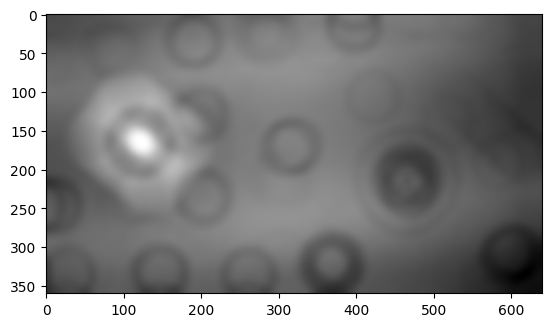

In [15]:
filtered_max = np.max(test_filtered_img.flatten())
filtered_min = np.min(test_filtered_img.flatten())
img_range = filtered_max - filtered_min
test_filtered_img = (test_filtered_img - filtered_min)/img_range
plt.imshow(test_filtered_img, cmap='gray')


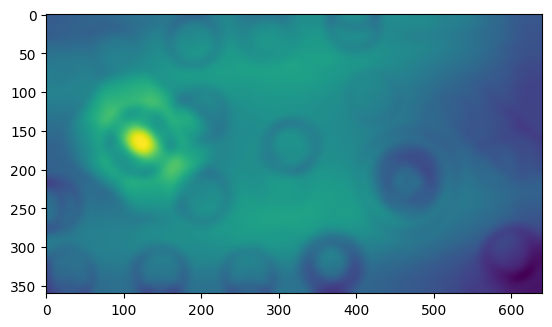

In [16]:
plt.imshow(test_filtered_img)

ret= 200.0


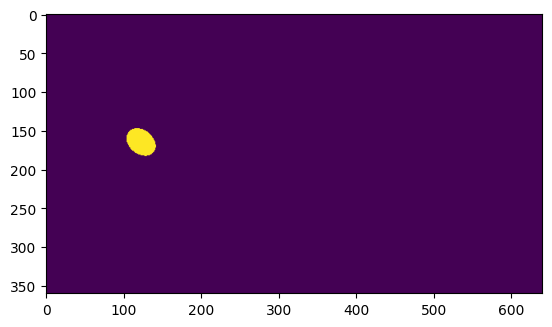

In [17]:
ret,filtered_thresholded = cv.threshold((test_filtered_img*255).astype(np.uint8),200,255,cv.THRESH_BINARY)
plt.imshow(filtered_thresholded)
print("ret=",ret)

In [18]:
np.max(blurred.flatten())

np.uint8(164)

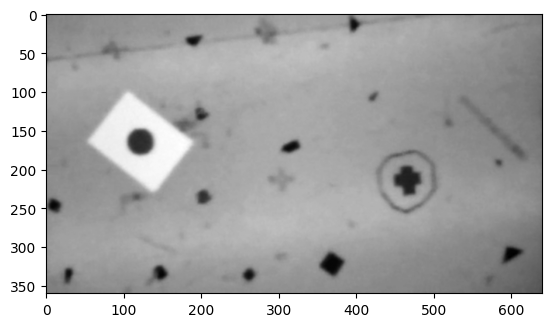

In [19]:
plt.imshow(blurred, cmap='gray')

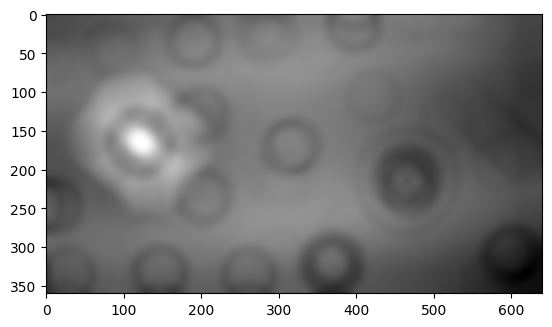

In [20]:
test_filtered_img_no_blur = cv.filter2D(img_gray/255.0, -1, circle_template, borderType=cv.BORDER_DEFAULT)
plt.imshow(test_filtered_img_no_blur, cmap='gray')

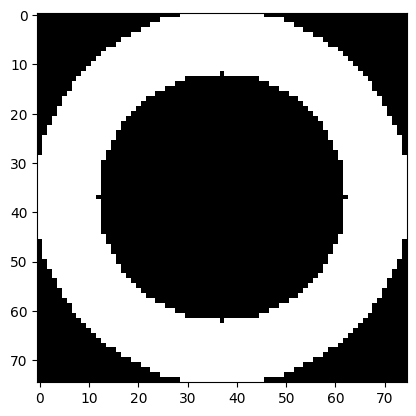

In [23]:
blank_new = np.zeros((75,75), np.uint8)
circle_template_0 = cv.circle(blank_new,(37,37),np.round(75/2).astype(np.uint8) , 255, -1)
circle_template = cv.circle(circle_template_0,(37,37),25 , 0, -1)
plt.imshow(circle_template, cmap='gray')


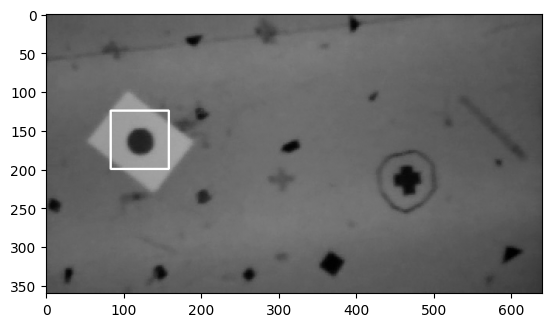

In [24]:
img_new = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

res = cv.matchTemplate(img_new,circle_template,cv.TM_CCOEFF)
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
top_left = max_loc
(w,h) = circle_template.shape
bottom_right = (top_left[0] + w, top_left[1] + h)
cv.rectangle(img_new,top_left, bottom_right, 255, 2)
plt.imshow(img_new, cmap='gray')

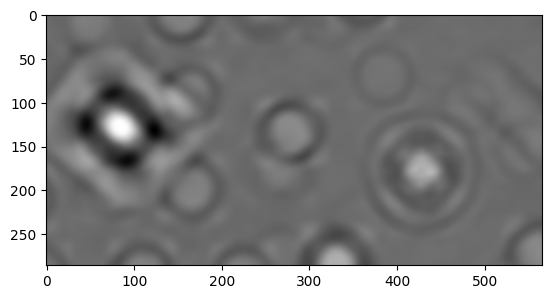

In [25]:
plt.imshow(res, cmap='gray')

In [53]:
# Ideas
# [DONE] Try template matching
# [DONE] try improving filter - outside all zeros, then one ring of ones, then inner ring of zeros
# [SKIP] after convolutional filter, try blob detection using Laplacian of Gaussians

# TODO
# [DONE] find image with different scale
# [DONE] idea - after finding first guess, optimize the following black circle radius, center
# [DONE] find image with multiple circles to test on
# [] get multi-circle detection working
# [DONE] try multi-scale
# different scale image - 2696
# multiple targets - 844 (partial obscured) 879 - 882img_new = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

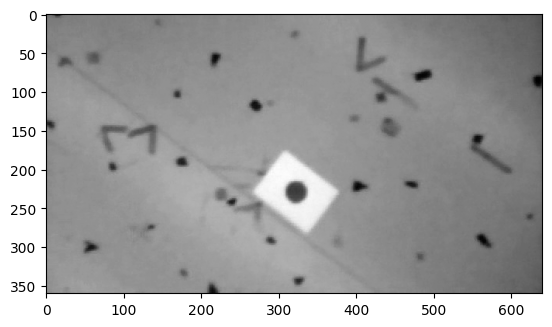

In [42]:

img_2696 = cv.imread(os.path.join(folder, "image_2696.jpg"), cv.IMREAD_GRAYSCALE)
plt.imshow(img_2696, cmap='gray')

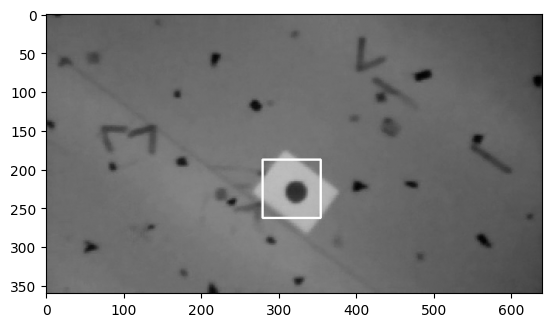

In [43]:
res = cv.matchTemplate(img_2696,circle_template,cv.TM_CCOEFF)
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
top_left = max_loc
(w,h) = circle_template.shape
bottom_right = (top_left[0] + w, top_left[1] + h)
cv.rectangle(img_2696,top_left, bottom_right, 255, 2)
plt.imshow(img_2696, cmap='gray')

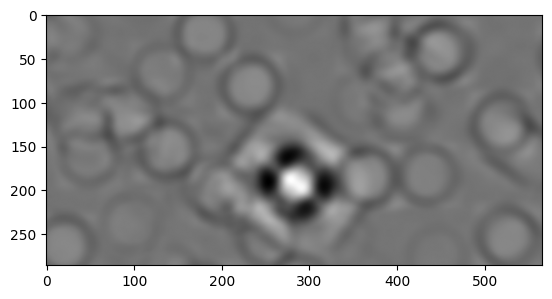

In [44]:
plt.imshow(res, cmap='gray')

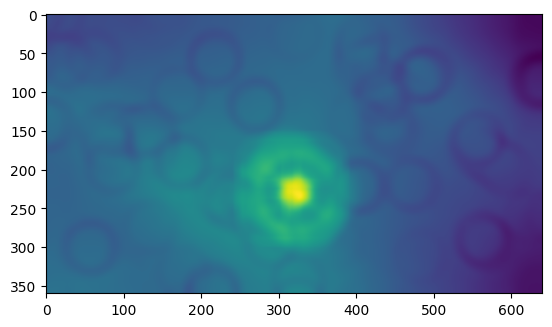

In [45]:
img2696_convolved = cv.filter2D(img_2696/255.0, -1, circle_template, borderType=cv.BORDER_DEFAULT)
plt.imshow(img2696_convolved)

In [46]:
max_pixel_idx = np.unravel_index(img2696_convolved.argmax(), img2696_convolved.shape)
max_pixel_idx

(np.int64(234), np.int64(327))

In [74]:
np.min(filtered_LoG)

np.int16(-300)

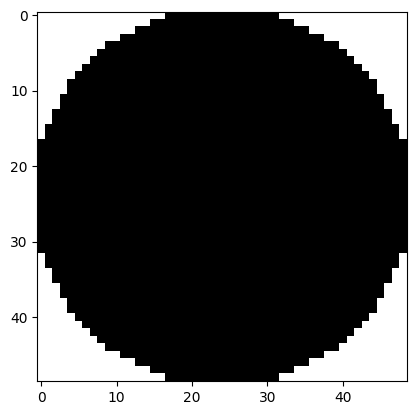

In [87]:
blank_new = np.ones((49,49), np.uint8)
circle_template = cv.circle(blank_new,(24,24),25, 0, -1)
plt.imshow(circle_template, cmap='gray')

In [249]:
img_2696 = cv.imread(os.path.join(folder, "image_2696.jpg"), cv.IMREAD_GRAYSCALE)

print(current_img.shape)

initial_y = max_pixel_idx[0]
initial_x = max_pixel_idx[1]

initial_radius = 24
best_parameters = refine_detection(img_2696, initial_x, initial_y, initial_radius)
print("best parameters", best_parameters)

(360, 640)
best parameters (308, 216, 14)


In [136]:
print(initial_x, initial_y, initial_radius)


327 234 24


In [137]:
print(best_parameters)

(308, 216, 14)


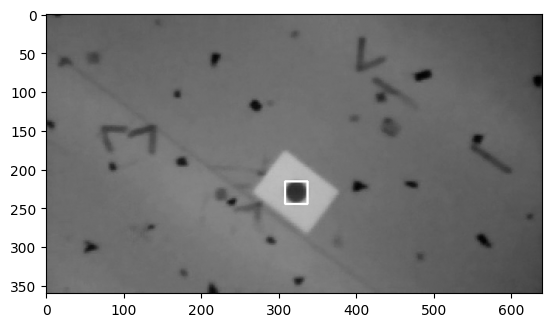

In [139]:
img_2696 = cv.imread(os.path.join(folder, "image_2696.jpg"), cv.IMREAD_GRAYSCALE)
best_y, best_x, best_r = best_parameters
w = 2*best_r + 1
top_left = (best_y, best_x)
bottom_right = (best_y + w, best_x + w)
cv.rectangle(img_2696,top_left, bottom_right, 255, 2)
plt.imshow(img_2696, cmap='gray')

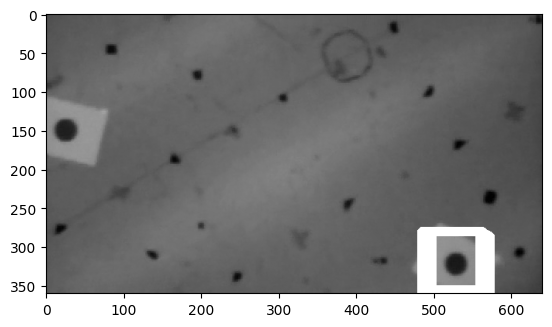

In [178]:
# multiple targets - 844 (partial obscured) 879 - 882

img_880 = cv.imread(os.path.join(folder, "image_880.jpg"), cv.IMREAD_GRAYSCALE)
current_img = img_880
blank_new = np.zeros((75,75), np.uint8)
circle_template_0 = cv.circle(blank_new,(37,37),np.round(75/2).astype(np.uint8) , 255, -1)
circle_template = cv.circle(circle_template_0,(37,37),25 , 0, -1)
res = cv.matchTemplate(current_img,circle_template,cv.TM_CCOEFF)

min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

threshold = 0.7 * max_val
locations = np.where( res >= threshold)
w, h = circle_template.shape[::-1]
for pt in zip(*locations[::-1]):
    top_left = pt
    bottom_right = (top_left[0] + w, top_left[1] + w)
    cv.rectangle(current_img, top_left, bottom_right, 255, 2)
# min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
# top_left = max_loc
# (w,h) = circle_template.shape
# bottom_right = (top_left[0] + w, top_left[1] + h)
# cv.rectangle(current_img,top_left, bottom_right, 255, 2)

plt.imshow(current_img, cmap='gray')
# best_y, best_x, best_r = best_parameters
# w = 2*best_r + 1
# top_left = (best_y, best_x)
# bottom_right = (best_y + w, best_x + w)
# cv.rectangle(img_2696,top_left, bottom_right, 255, 2)
# plt.imshow(img_2696, cmap='gray')

In [180]:
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)


In [181]:
corner_zip = zip(*locations[::-1])
print(len(list(corner_zip)))

163


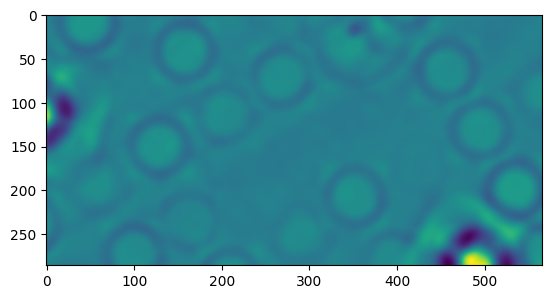

In [182]:
plt.imshow(res)


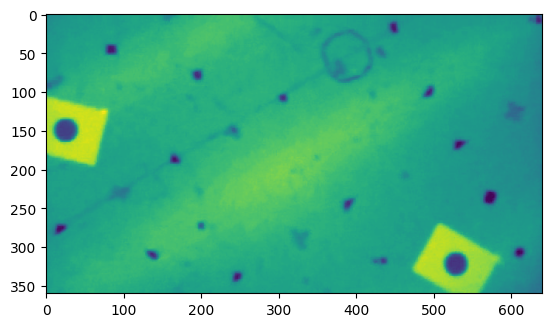

In [189]:
img_880 = cv.imread(os.path.join(folder, "image_880.jpg"), cv.IMREAD_GRAYSCALE)
current_img = img_880
plt.imshow(current_img)


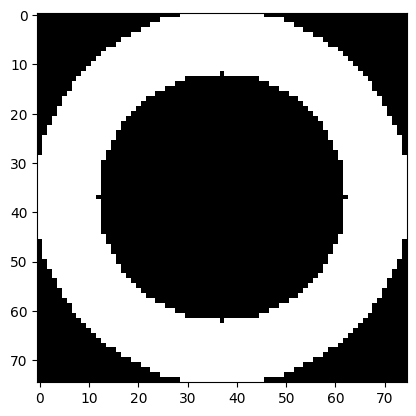

In [254]:
blank_new = np.zeros((75,75), np.uint8)
circle_template_0 = cv.circle(blank_new,(37,37),np.round(75/2).astype(np.uint8) , 1, -1)
circle_template = cv.circle(circle_template_0,(37,37),25 , 0, -1)
plt.imshow(circle_template, cmap='gray')


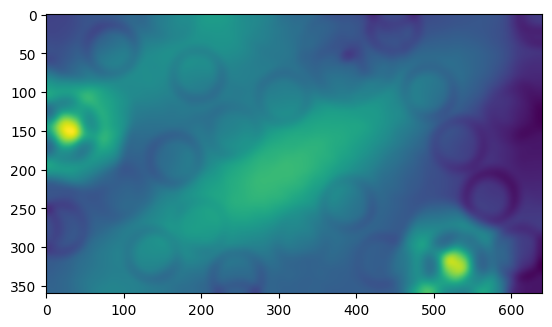

In [255]:
convolved = cv.filter2D(current_img/255.0, -1, circle_template, borderType=cv.BORDER_DEFAULT)
plt.imshow(convolved)

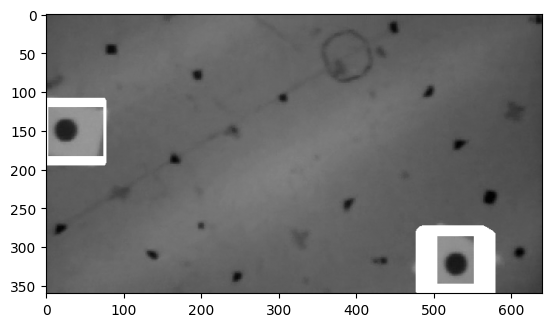

In [256]:
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

threshold = 0.7 * max_val
locations = np.where( res >= threshold)
w, h = circle_template.shape[::-1]

img_markup = current_img.copy()

for pt in zip(*locations[::-1]):
    top_left = pt
    bottom_right = (top_left[0] + w, top_left[1] + w)
    cv.rectangle(img_markup, top_left, bottom_right, 255, 2)

plt.imshow(img_markup, cmap='gray')

255
0
ret= 200.0


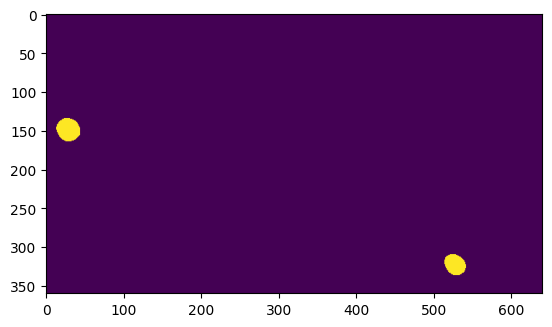

In [257]:
normalized = (convolved - np.min(convolved.flatten())) / (np.max(convolved) - np.min(convolved))
normalized = (normalized*255).astype(np.uint8)
print(np.max(normalized.flatten()))
print(np.min(normalized.flatten()))
ret,filtered_thresholded = cv.threshold(normalized,200,255,cv.THRESH_BINARY)
plt.imshow(filtered_thresholded)
print("ret=",ret)

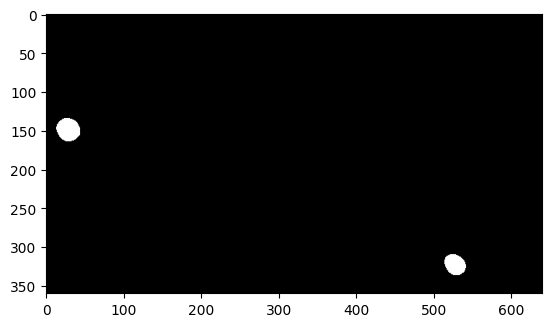

In [233]:
# Setup SimpleBlobDetector parameters
params = cv.SimpleBlobDetector_Params()
 
# Thresholds for binarization
params.minThreshold = 200
params.maxThreshold = 255
 
# Filter by Area
params.filterByArea = False
params.minArea = 14*14
params.maxArea = 75*75
 
# Filter by Circularity
params.filterByCircularity = False
params.minCircularity = 0.1
 
# Filter by Convexity
params.filterByConvexity = False
params.minConvexity = 0.87
 
# Filter by Inertia
params.filterByInertia = False
params.minInertiaRatio = 0.01
 
# Create a detector with the parameters
detector = cv.SimpleBlobDetector_create(params)
 
# Detect blobs
keypoints = detector.detect(filtered_thresholded)
 
# Draw blobs as red circles
output = cv.drawKeypoints(filtered_thresholded, keypoints, np.array([]), (0, 0, 255),
                           cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
 
# Show the output
plt.imshow(output)

In [234]:
keypoints

()

In [226]:
w

75

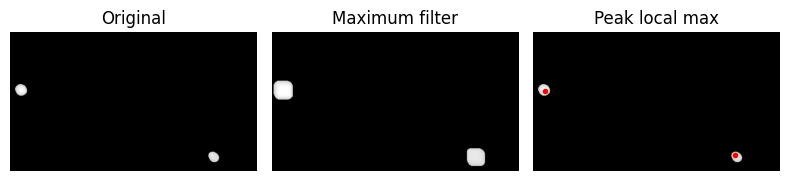

In [244]:
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max
from skimage import data, img_as_float

im = filtered_thresholded/255.0 * normalized

# image_max is the dilation of im with a 20*20 structuring element
# It is used within peak_local_max function
image_max = ndi.maximum_filter(im, size=20, mode='constant')

# Comparison between image_max and im to find the coordinates of local maxima
coordinates = peak_local_max(im, min_distance=20)

# display results
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharex=True, sharey=True)
ax = axes.ravel()
ax[0].imshow(im, cmap=plt.cm.gray)
ax[0].axis('off')
ax[0].set_title('Original')

ax[1].imshow(image_max, cmap=plt.cm.gray)
ax[1].axis('off')
ax[1].set_title('Maximum filter')

ax[2].imshow(im, cmap=plt.cm.gray)
ax[2].autoscale(False)
ax[2].plot(coordinates[:, 1], coordinates[:, 0], 'r.')
ax[2].axis('off')
ax[2].set_title('Peak local max')

fig.tight_layout()

plt.show()

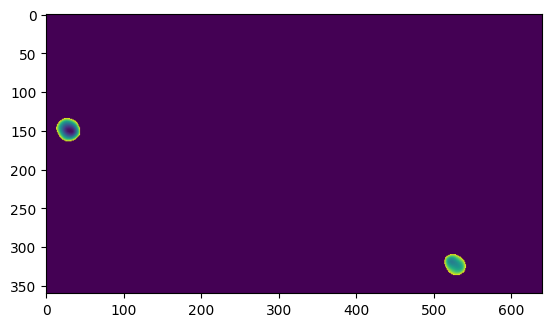

In [240]:
plt.imshow(filtered_thresholded * normalized)

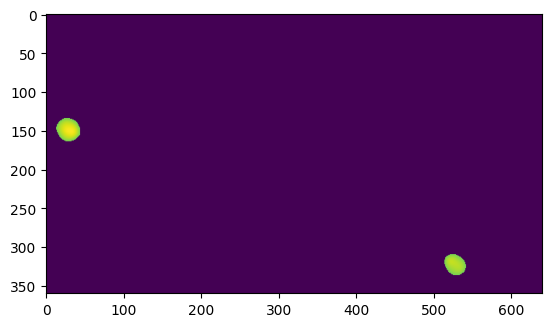

In [243]:
plt.imshow(filtered_thresholded/255.0 * normalized)

In [247]:
def refine_detection(current_img, initial_x, initial_y, initial_radius=24, radius_delta=10, position_delta=20):
    
    min_radius = initial_radius - radius_delta
    max_radius = initial_radius + radius_delta
    min_x = initial_x - position_delta
    max_x = initial_x + position_delta + 1
    
    min_y = initial_y - position_delta
    max_y = initial_y + position_delta + 1
    
    min_error = np.inf
    best_parameters = (0,0,0)
    
    for x in range(min_x, max_x):
        for y in range(min_y, max_y):
            for r in range(min_radius, max_radius):
                w = r * 2 + 1
                if x <= 0:
                    continue
                if x >= current_img.shape[1] - w:
                    continue
                if y <= 0:
                    continue
                if y >= current_img.shape[0] - w:
                    continue
                blank_new = np.ones((w,w), np.uint8)
                circle_template = cv.circle(blank_new,(r,r),r, 0, -1)
                img_slice = current_img[y:y+w, x:x+w]
                error = np.sum(np.abs(img_slice - circle_template))
    
                if(error < min_error):
                    min_error = error
                    best_parameters = (x,y,r)
    return best_parameters


best parameters (11, 136, 14)
best parameters (515, 308, 14)


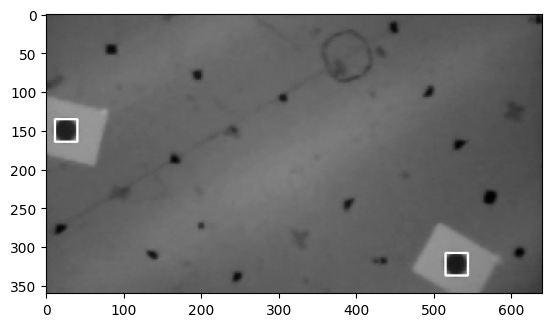

In [253]:
initial_radius = 24
img_annotated = current_img.copy()

for coord in coordinates:
    initial_x = coord[1]
    initial_y = coord[0]
    best_parameters = refine_detection(current_img, initial_x, initial_y, initial_radius)
    print("best parameters", best_parameters)
    best_y, best_x, best_r = best_parameters
    w = 2*best_r + 1
    top_left = (best_y, best_x)
    bottom_right = (best_y + w, best_x + w)
    cv.rectangle(img_annotated,top_left, bottom_right, 255, 2)
plt.imshow(img_annotated, cmap='gray')

In [251]:
initial_x

array([ 31, 522])

In [259]:
def initial_detection(current_img, filter):
    convolved = cv.filter2D(current_img/255.0, -1, circle_template, borderType=cv.BORDER_DEFAULT)
    normalized = (convolved - np.min(convolved.flatten())) / (np.max(convolved) - np.min(convolved))
    normalized = (normalized*255).astype(np.uint8)
    ret,filtered_thresholded = cv.threshold(normalized,200,255,cv.THRESH_BINARY)

    im = filtered_thresholded/255.0 * normalized
    image_max = ndi.maximum_filter(im, size=20, mode='constant')
    coordinates = peak_local_max(im, min_distance=20)
    return coordinates

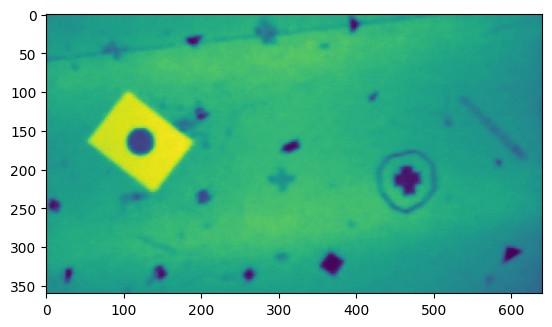

In [260]:
# "image_512.jpg"
current_img = cv.imread(os.path.join(folder, "image_512.jpg"), cv.IMREAD_GRAYSCALE)
plt.imshow(current_img)

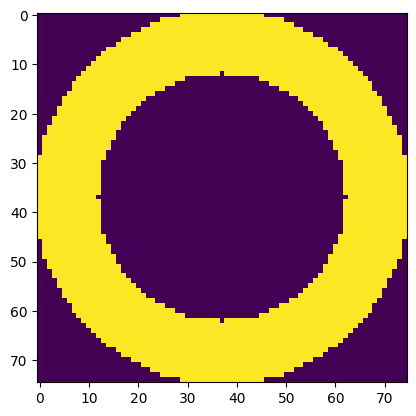

In [261]:
plt.imshow(circle_template)

In [264]:
centers = initial_detection(current_img, circle_template)

print(centers)

[[166 124]]


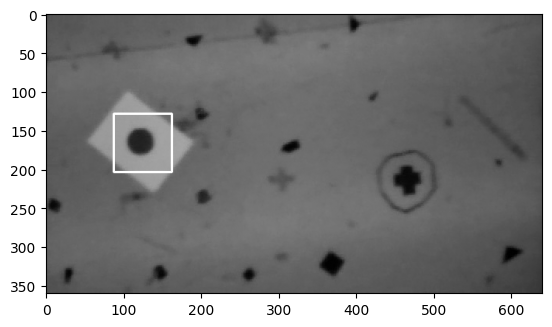

In [268]:
img_markup = current_img.copy()
h,w = circle_template.shape
initial_radius = 24
for pt in centers:
    top_left = (pt[1]- int(w/2),pt[0] - int(w/2))
    bottom_right = (top_left[0] + w, top_left[1] + w)
    cv.rectangle(img_markup, top_left, bottom_right, 255, 2)

plt.imshow(img_markup, cmap='gray')

best parameters (107, 151, 14)


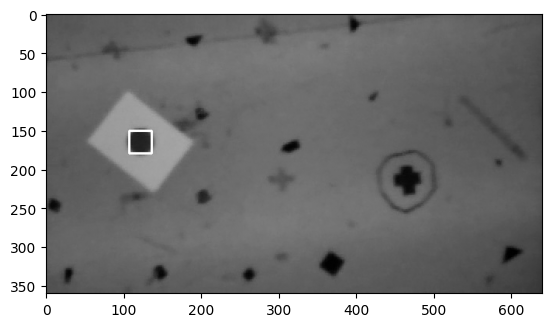

In [269]:
img_annotated = current_img.copy()

for coord in centers:
    initial_x = coord[1]
    initial_y = coord[0]
    best_parameters = refine_detection(current_img, initial_x, initial_y, initial_radius)
    print("best parameters", best_parameters)
    best_y, best_x, best_r = best_parameters
    w = 2*best_r + 1
    top_left = (best_y, best_x)
    bottom_right = (best_y + w, best_x + w)
    cv.rectangle(img_annotated,top_left, bottom_right, 255, 2)
plt.imshow(img_annotated, cmap='gray')

In [278]:
# import OS module
import os
# Get the list of all files and directories
folder = "data/image_folder"
dir_list = (os.listdir(folder))
print("Files and directories in '", folder, "' :")
# prints all files
num_files = len(dir_list)


Files and directories in ' data/image_folder ' :
2892
image_0.jpg
image_1005.jpg
image_1006.jpg
image_999.jpg


image_0.jpg
image_150.jpg
image_300.jpg
image_450.jpg
image_600.jpg
image_750.jpg
image_900.jpg
image_1050.jpg
image_1200.jpg
image_1350.jpg
image_1500.jpg
image_1650.jpg
image_1800.jpg
image_1950.jpg
image_2100.jpg
image_2250.jpg
image_2400.jpg
image_2550.jpg
image_2700.jpg


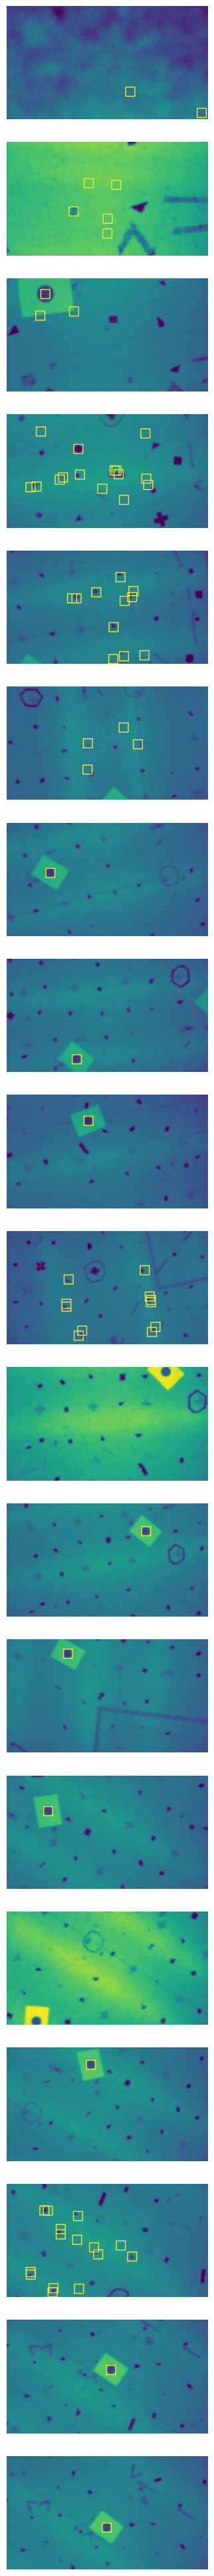

In [290]:
# create filter template
blank_new = np.zeros((75,75), np.uint8)
circle_template_0 = cv.circle(blank_new,(37,37),np.round(75/2).astype(np.uint8) , 1, -1)
circle_template = cv.circle(circle_template_0,(37,37),25 , 0, -1)

skip = 150

num_images = int(num_files/skip)
fig, axes = plt.subplots(num_images, 1, figsize=(150, 50))

img_numbers = range(0, num_files, skip)
for ax, img_idx in zip(axes, img_numbers):
    img_file_name = "image_" + str(img_idx) + ".jpg"
    print(img_file_name)
    current_img = cv.imread(os.path.join(folder, img_file_name), cv.IMREAD_GRAYSCALE)
    img_annotated = current_img.copy()

    # 2D convolutional filter for template matching
    centers = initial_detection(current_img, circle_template)

    # Refine detection
    for coord in centers:
        initial_x = coord[1]
        initial_y = coord[0]
        best_parameters = refine_detection(current_img, initial_x, initial_y, initial_radius)
        # print("best parameters", best_parameters)
        best_y, best_x, best_r = best_parameters
        w = 2*best_r + 1
        top_left = (best_y, best_x)
        bottom_right = (best_y + w, best_x + w)
        cv.rectangle(img_annotated,top_left, bottom_right, 255, 2)

        # Display annotated image
    ax.imshow(img_annotated)
    ax.axis('off')  # Hide axes
plt.show()

In [292]:
def detect_all_targets(current_img):
    # create filter template
    blank_new = np.zeros((75,75), np.uint8)
    circle_template_0 = cv.circle(blank_new,(37,37),np.round(75/2).astype(np.uint8) , 1, -1)
    circle_template = cv.circle(circle_template_0,(37,37),25 , 0, -1)

    centers = initial_detection(current_img, circle_template)

    results = [] #x,y,r
    for coord in centers:
        initial_x = coord[1]
        initial_y = coord[0]
        best_parameters = refine_detection(current_img, initial_x, initial_y, initial_radius)
        results.append(best_parameters)
    
    return results

filename:  image_2700.jpg
path:  data/image_folder/image_2700.jpg


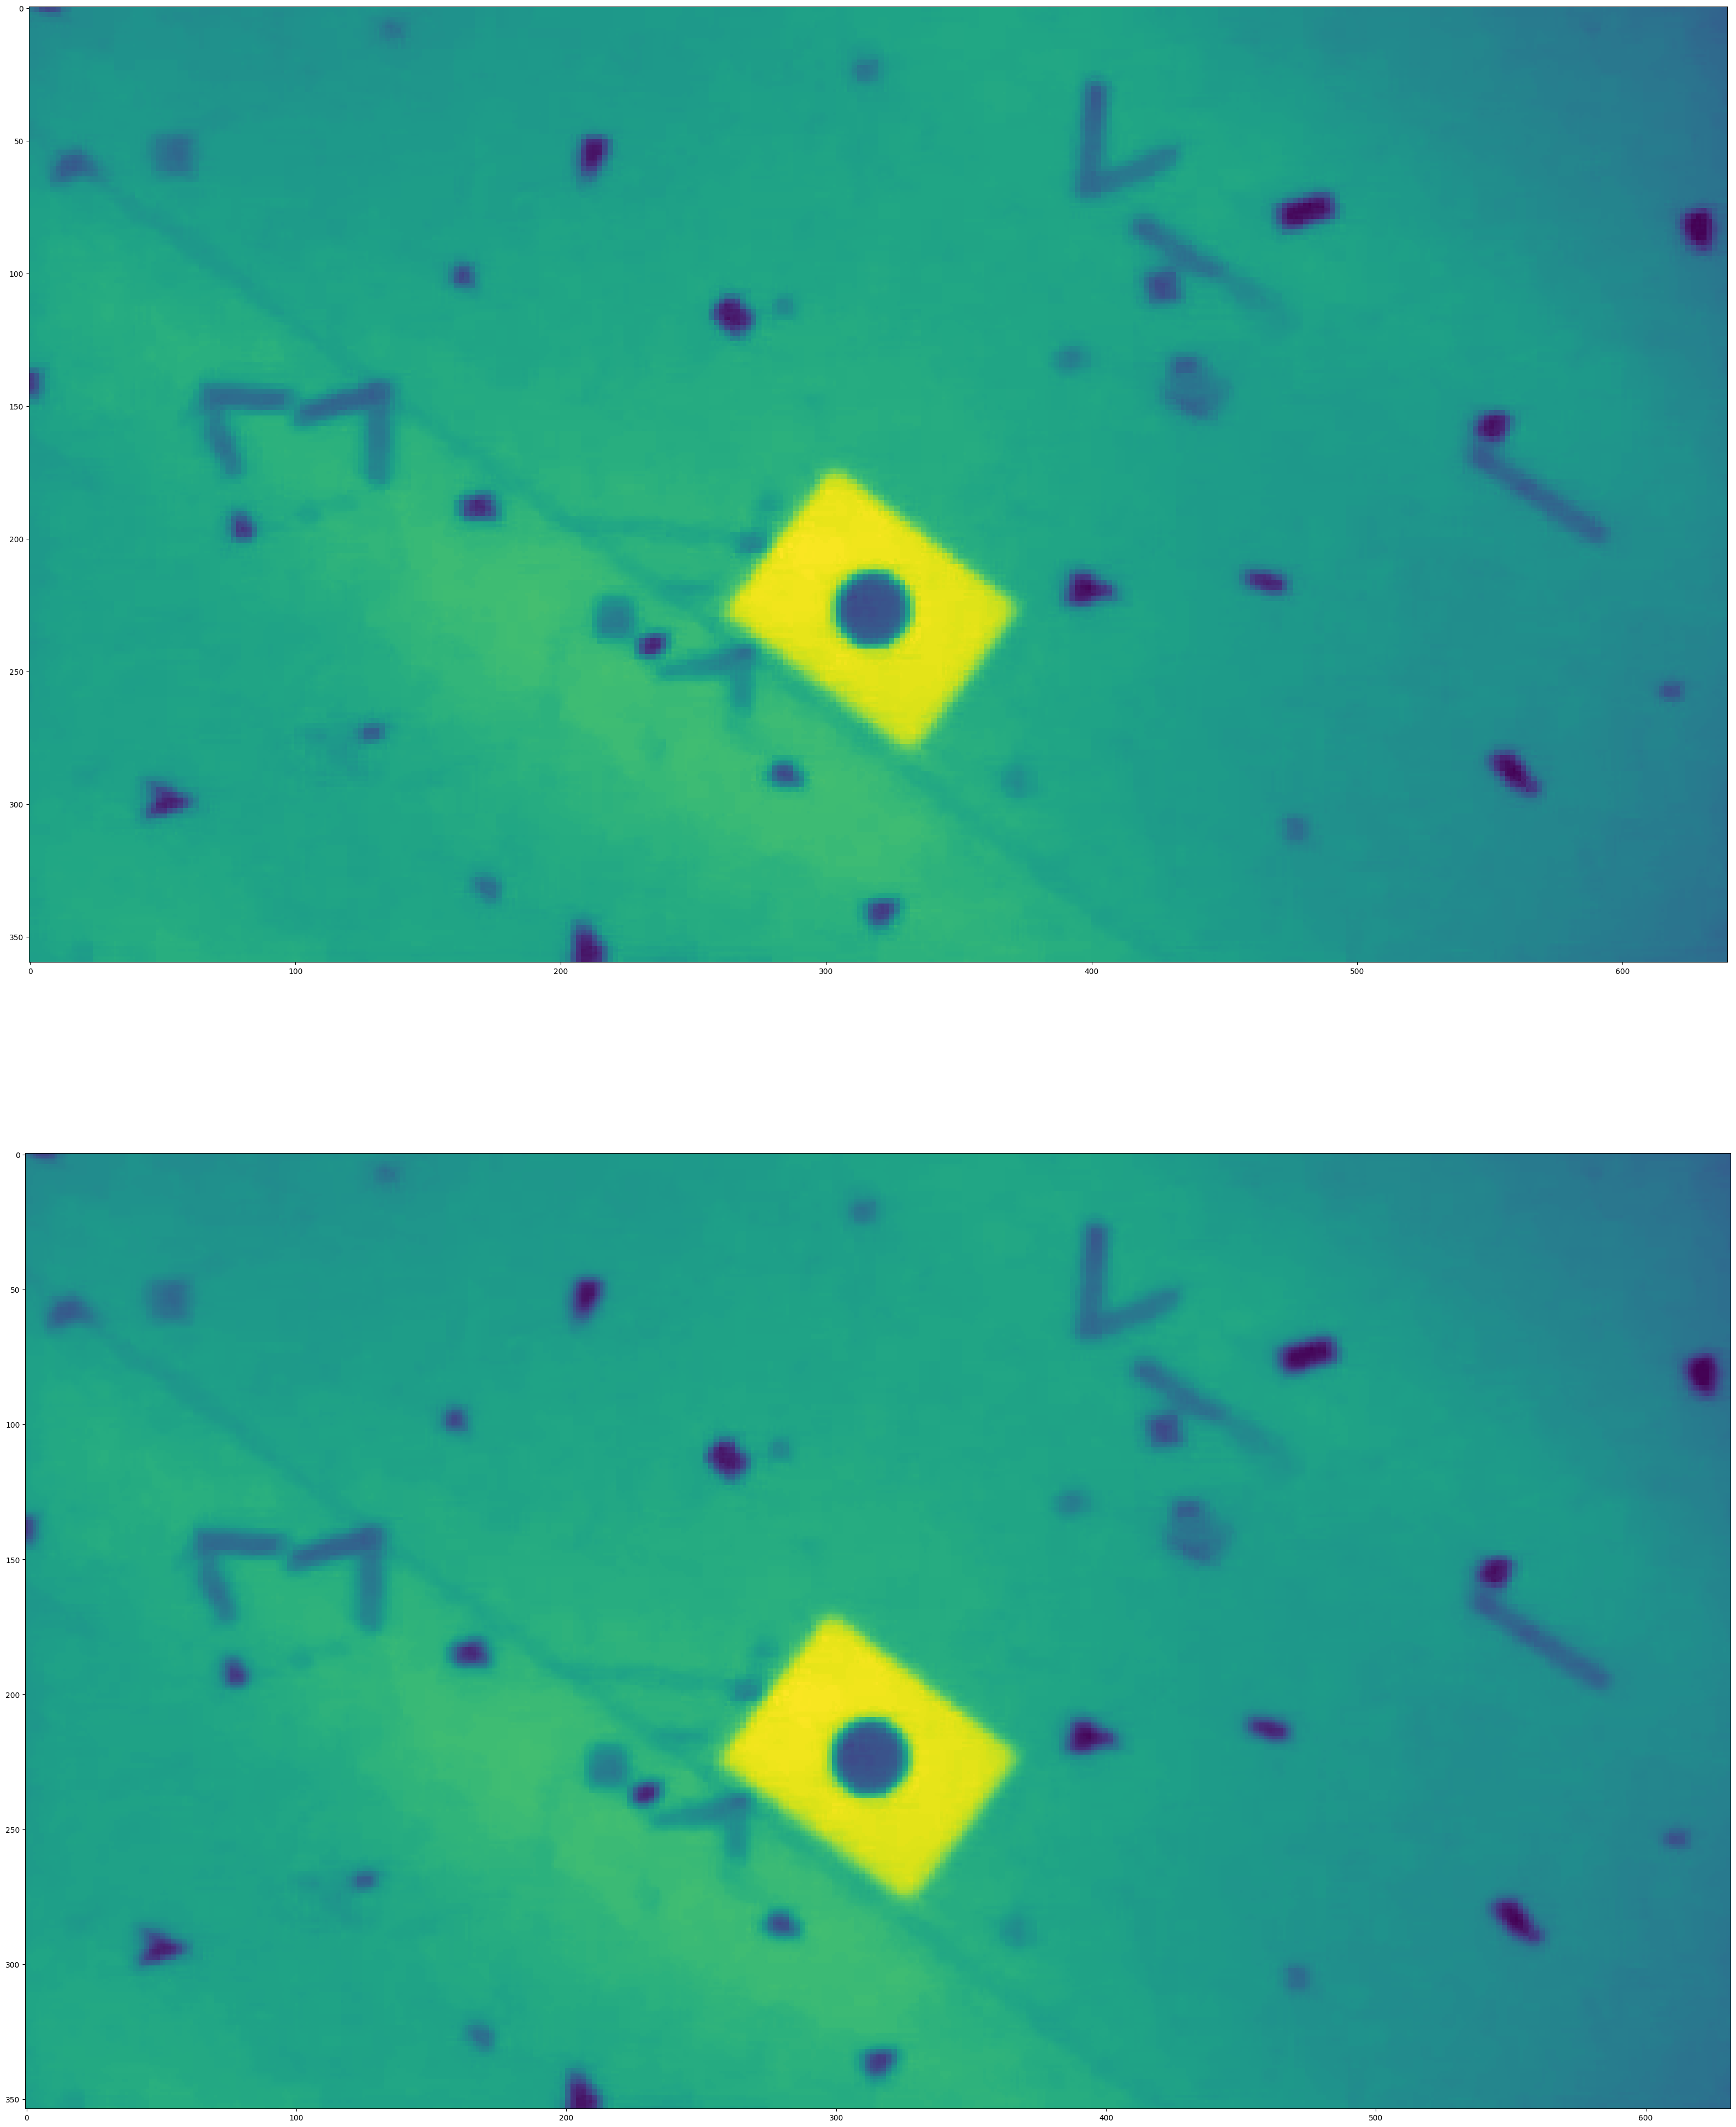

In [308]:
current_idx = 2700
current_img_file_name = "image_" + str(current_idx) + ".jpg"
img_folder = "data/image_folder"
current_img_path = os.path.join(img_folder,current_img_file_name)
print("filename: ", current_img_file_name)
print("path: ", current_img_path)

current_img = cv.imread(current_img_path, cv.IMREAD_GRAYSCALE)

h,  w = current_img.shape[:2]
camera_matrix = np.array([698.86, 0.0, 306.91, 0.0, 699.13, 150.34, 0.0, 0.0, 1.0]).reshape((3,3))
distortion_coefficients = np.array([0.191887, -0.563680, -0.003676, -0.002037, 0.0])

fig, axes = plt.subplots(2, 1, figsize=(150, 50))

newcameramtx, roi = cv.getOptimalNewCameraMatrix(camera_matrix, distortion_coefficients, (w,h), 1, (w,h))
img_rectified = cv.undistort(current_img, camera_matrix, distortion_coefficients, None, newcameramtx)
# crop the image
x, y, w, h = roi
img_rectified = img_rectified[y:y+h, x:x+w]
# cv.imwrite('calibresult.png', dst)

# ax.axis('off')  # Hide axes
axes[0].imshow(current_img)
axes[1].imshow(img_rectified)

plt.show()


In [319]:

print(newcameramtx)
print(camera_matrix)



[[702.04706109   0.         305.0099728 ]
 [  0.         700.49271415 149.16115525]
 [  0.           0.           1.        ]]
[[698.86   0.   306.91]
 [  0.   699.13 150.34]
 [  0.     0.     1.  ]]


In [295]:
results_unrect = detect_all_targets(current_img)
results_rect = detect_all_targets(img_rectified)

In [296]:
print(results_unrect)
print(results_rect)

[(303, 213, 14)]
[(299, 209, 14)]


In [300]:
folder = "data"
file_name = "lab3_pose.csv"
pose_file = os.path.join(folder, file_name)
pose_data = np.loadtxt(pose_file, skiprows=1,  delimiter=",")



data/lab3_pose.csv


In [301]:
pose_data[0]

array([ 0.00000e+00, -1.52195e+00,  1.36339e+00,  9.43046e-02,
        7.43646e-01, -1.71519e-06,  1.59058e-02, -6.68384e-01])

In [310]:
current_pose = pose_data[current_idx]
print(current_pose)

[ 2.70000e+03 -1.29566e+00  1.13243e+00  2.24276e+00  4.48803e-01
 -2.20950e-02 -1.33671e-02  8.93258e-01]


In [329]:
from scipy.spatial.transform import Rotation as Rot

def compute_target_inertial_pose(pose_quad, pixels, camera_mtx, projection_mtx):
    # pose_quad - px, py, pz, qw, qx, qy, qz 
    # Inertial Frame
    vehicle_position = np.array([pose_quad[0], pose_quad[1], pose_quad[2]]).reshape(3,1)
    vehicle_orientation_quat = np.array(pose_quad[3:7])
    r_obj = Rot.from_quat(vehicle_orientation_quat, scalar_first=True)
    # QUESTION! is this rotation from the body frame to inertial, or inertial to body frame?
    R = r_obj.as_matrix()
    # r.apply()
    zhat = [0,0,-1]
    Pw_hat = R @ zhat
    # 'Camera's World frame'
    cos_alpha = np.dot(Pw_hat, zhat)
    Zq = vehicle_position[2] # pz
    Zw = Zq / cos_alpha

    fx = camera_mtx[0,0]
    cx = camera_mtx[0,2]

    fy = camera_mtx[1,1]
    cy = camera_mtx[1,2]

    (u,v) = pixels
    Yw = (u-cx)/fx * Zw
    Xw = (v-cy)/fy * Zw

    Pw = np.array([Xw,Yw, Zw])

    Pe =  Pq - R @ Pw

    return Pe, Pw

In [330]:

# pose_quad - px, py, pz, qw, qx, qy, qz 
# Inertial Frame
pose_quad = current_pose[1:,]
pixels = (results_rect[0][0], results_rect[0][1])
camera_mtx = newcameramtx.reshape(3,3)

In [333]:
Pe_test, Pw_test = compute_target_inertial_pose(pose_quad, pixels, camera_mtx, None)
print(Pe_test.flatten())
print(Pw_test.flatten())
print(pose_quad[0:3])
    

[-1.0810999   0.97611692  0.00443038]
[ 0.19184125 -0.0192251   2.24575524]
[-1.29566  1.13243  2.24276]
